<a href="https://colab.research.google.com/github/NU-MSE-LECTURES/465-WINTER2026/blob/main/Week_05/code_examples/example_05_abTEM_TEM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 05 - Example 05: abTEM HRTEM Simulation

This notebook demonstrates **abTEM** for simulating High-Resolution Transmission Electron Microscopy (HRTEM) of **Gallium Arsenide (GaAs)** oriented along the **[110]** zone axis.

Key topics covered:
1. Building atomic models using `ase`.
2. Orthogonalizing unit cells for multislice simulation.
3. Calculating frozen phonon potentials.
4. Multislice propagation of electron wavefunctions.
5. Contrast Transfer Function (CTF) application (Aberration Correction vs. Conventional).

In [124]:
# for colab
# python package installation
!pip install abtem > /dev/null 2>&1
# !pip install git+https://github.com/abtem/abtem.git@master > /dev/null 2>&1

In [125]:
# Here we install the packages we will use in this tutorial
%matplotlib inline

# --- Patch for Python < 3.11 ---
# The 'Self' type hint was added to the 'typing' module in Python 3.11.
# Your environment is using Python 3.10, so we need to inject 'Self' 
# from 'typing_extensions' into 'typing' before importing abTEM.
import sys
import typing

if sys.version_info < (3, 11):
    try:
        from typing_extensions import Self
        if not hasattr(typing, "Self"):
            typing.Self = Self
    except ImportError:
        print("Warning: 'typing_extensions' library not found. Please install it with: !pip install typing_extensions")
# -------------------------------

import abtem                      # simulation code
import ase                        # handle atomic coordinates, unit cells, etc.
import numpy as np                # numerical functions
import matplotlib.pyplot as plt   # plotting functions

## Build atomic model - GaAs [110]

We'll use the atomic simulation environment (`ase`) package to build our unit-cell.

We will create a **Zincblende GaAs** crystal ($a=5.65$ Å) and specifically orient it along the **[110] direction**.
This requires:
1. Creating the bulk crystal.
2. Checking the vectors.
3. Defining a surface/cut to align [110] with the propagation axis ($z$).


Cell Dimensions: 3.9975 x 5.6533 x 3.9975 Å
Structure created explicitly from Kirkland Table 7.1


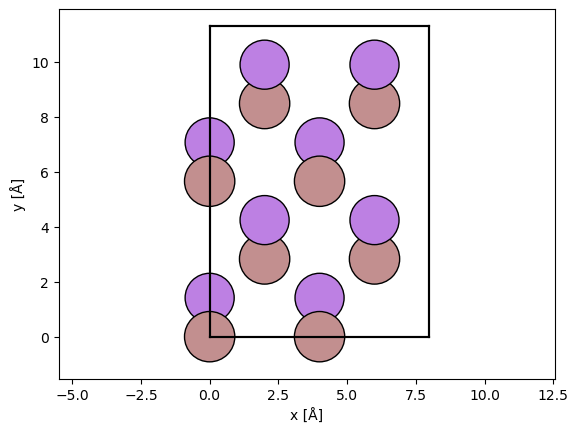

In [126]:
# Create atomic structure manually based on Kirkland Table 7.1
# Lattice constant
a_gaas = 5.6533 

# Rectangular cell dimensions for [110] projection
# Z is the beam direction [110]
# X is a0 = a/sqrt(2) ~ 4.0
# Y is b0 = a ~ 5.65.
a0 = a_gaas / np.sqrt(2) # 3.9975
b0 = a_gaas              # 5.6533
c0 = a_gaas / np.sqrt(2) # 3.9975 (Thickness of 2 layers)

print(f"Cell Dimensions: {a0:.4f} x {b0:.4f} x {c0:.4f} Å")

# Coordinates from Table 7.1
# Stacking sequence ABAB...
# Layer A (z=0)
# Ga: 0, 0
# As: x=0.5, y=0.75
# Layer B (z=c0/2 = 1.998)
# As: 0, 0.25
# Ga: 0.5, 0.5
# Note: Coordinates are fractional w.r.t a0 and b0

positions = [
    (0, 0, 0),                       # Ga Layer A
    (0.5 * a0, 0.75 * b0, 0),        # As Layer A
    (0, 0.25 * b0, c0/2),            # As Layer B
    (0.5 * a0, 0.5 * b0, c0/2)       # Ga Layer B
]

symbols = ['Ga', 'As', 'As', 'Ga']

structure = ase.Atoms(symbols, positions=positions, cell=[a0, b0, c0], pbc=True)
structure_orthogonal = structure # Already orthogonal

print("Structure created explicitly from Kirkland Table 7.1")
abtem.show_atoms(structure * (2,2,1), plane='xy');

The created cell should typically be orthogonal by construction when using specific high-symmetry cuts like (110) on a cubic lattice. However, it's good practice to ensure it. 

If we have an orthogonal cell, the off-diagonal terms in the matrix should be close to zero.


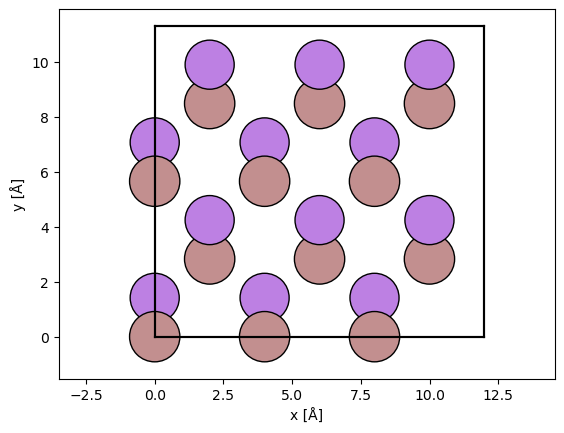

In [127]:
structure_orthogonal = abtem.orthogonalize_cell(structure)
abtem.show_atoms(structure_orthogonal * (3,2,1), plane='xy');

Note how the unit cell edges are now 90 degrees.  Try plotting different projection directions ('xz' or 'yz') to check the out-of-plane unit cell angles.

For arbitrary unit cell angles / lengths, we might need to construct a "rational approximate" unit cell, in order to force the corners to be 90 degrees.  For example we might find a tiling which produces an angle of 89 degrees, and then force it to be 90 degrees. This slight change will barely affect the simulation at all, but you must take care when comparing to experimental data to use the correct cell angles (for example by resampling the simulation output).

## Calculate projected potentials

We will calculate 8 frozen phonon configurations. 
We tile the unit cell to ensure an in-plane FOV > 20 Å.
For the thickness (beam direction), we tile it to reach a reasonable sample thickness (~5-10 nm).

RMS thermal displacements ($u$) depend on temperature and Debye-Waller factors.
For GaAs at room temperature:
- As: $B \approx 0.6 \implies u \approx \sqrt{B/8\pi^2} \approx 0.087$ Å.
- Ga: $B \approx 0.6 \implies u \approx 0.087$ Å.
We'll use typical values around 0.08-0.1 Å.


In [128]:
# Adjust tiling for the new cell dimensions.
# Cell is ~4x5.6 Angstroms.
nx_tile = 6 
ny_tile = 4 
nz_tile = 20 # Thickness (since one cell is only ~4A thick)

frozen_phonons = abtem.FrozenPhonons(
    structure_orthogonal * (nx_tile, ny_tile, nz_tile),
    8,
    {'Ga' : 0.08, 'As' : 0.08}, # Approximate thermal displacements
    seed=1,
)

Next, let's calculate the atomic potentials corresponding to each of these frozen phonon configurations. We will use a pixel size sampling of 0.1 Angstroms, a slice thickness of 2 Angstroms, and the (infinite) Kirkland potentials.

In [129]:
# abtem.Potential?

In [130]:
potential = abtem.Potential(
    frozen_phonons,
    sampling = 0.1,
    slice_thickness = 2.0,
    projection = 'infinite',
    parametrization = 'kirkland',
)

Let's check the array size of our potential:

In [131]:
potential.build().array.shape

(8, 40, 240, 227)

This is storing pre-computed arrays of atomic potentials with in-plane dimensions 228x263 pixels, for each of 25 z-slices, for each of our 8 frozen-phonon configurations.

Let's plot the mean-projected potential for all our frozen-phonon configurations along the slice-direction:

tasks:   0%|          | 0/17 [00:00<?, ?it/s]

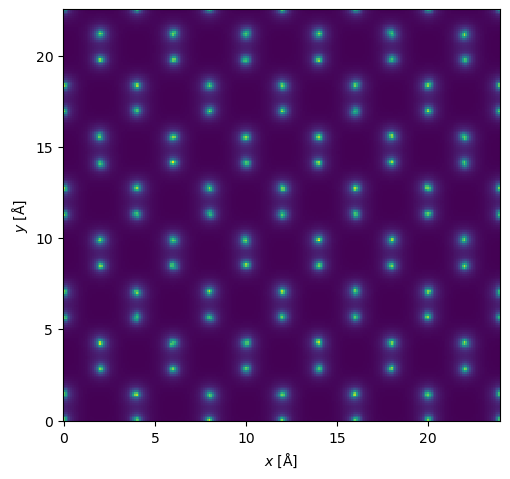

In [132]:
potential.project().show(cmap='viridis');

## HRTEM plane wave multislice simulation

We first initialize a plane wave with an accelerating voltage of 300kV, and then use the multislice algorithm to propagate it through each projected potential slice.

In [133]:
wave = abtem.PlaneWave(energy=300e3)
exit_waves = wave.multislice(potential)

Let's check the size of the output - we should have 8 exit waves, one for each of our frozen phonon configurations.

In [134]:
exit_waves.array.shape

(8, 240, 227)

Plot the exit wave intensities for a single frozen phonon configuration, and the mean of all configurations


tasks:   0%|          | 0/4 [00:00<?, ?it/s]

tasks:   0%|          | 0/32 [00:00<?, ?it/s]

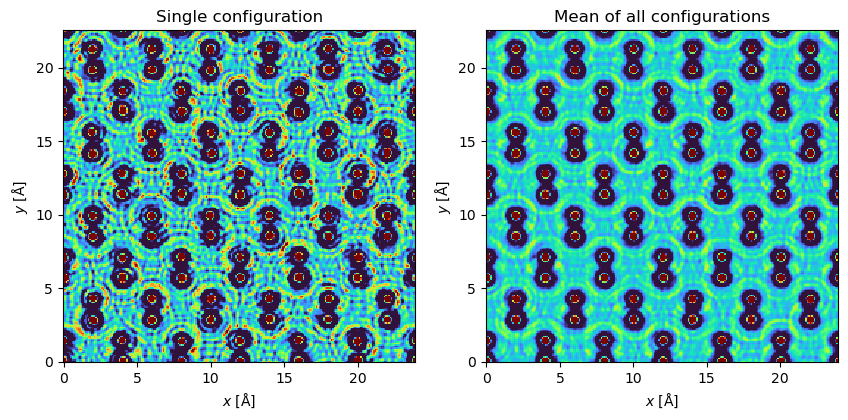

In [135]:
fig, ax = plt.subplots(1, 2, figsize=(10,5))

exit_waves.intensity()[0].show(
    ax = ax[0],
    cmap='turbo',
    vmin = 0.5,
    vmax = 2.0,
)
ax[0].set_title('Single configuration');

exit_waves.intensity().mean(0).show(
    ax = ax[1],
    cmap='turbo',
    vmin = 0.5,
    vmax = 2.0,
)
ax[1].set_title('Mean of all configurations');

Notice how in the single configuration, we can see many "ripples" in the exit waves. These are causes by the various random atomic displacements - however when we average 8 configurations, the intensities are far more uniform. For this sample (5 nm thickness) we would recommend using 16 or even 32 frozen phonon configurations, but for the purposes of this tutorial 8 is enough.

## Contrast transfer functions

Here we define a contrast transfer function (CTF) - note the units must always be in Angstroms!  The most important terms in our CTF are the radially symmetric aberrations:

- C10 - defocus
- C30 - 3rd order spherical aberration
- C50 - 5th order spherical aberration.



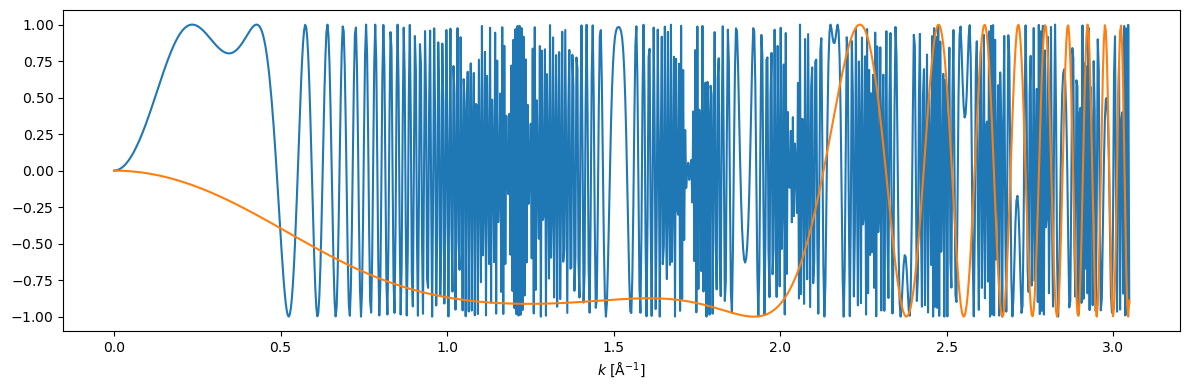

In [136]:
# No aberration correction
aberration_coefficients = {
    "C10": -600,
    "C30": 1.3e7,  # 1.3 mm -> Å
    "C50": 5e7,    # 5.0 mm -> Å
}

ctf = abtem.CTF(
    energy=300e3,
    aberration_coefficients=aberration_coefficients,
)

# Aberration corrected, negative Cs imaging
aberration_coefficients_corrected = {
    "C10": 30,
    "C30": -8e4,
    "C50": 5e7,
}

ctf_corrected = abtem.CTF(
    energy=300e3,
    aberration_coefficients=aberration_coefficients_corrected,
)

fig, ax = plt.subplots(figsize=(12, 4))

ctf.profiles(max_angle=60).show(ax=ax, units="mrad", legend=True)
ctf_corrected.profiles(max_angle=60).show(ax=ax, units="mrad", legend=True)

fig.tight_layout()


Compare the CTF plots shown above between the corrected and uncorrected TEMs. What is the maximum scattering angle where the information is "interpretable" (meaning a roughly flat CTF) for both cases?  Are there any ways the aberration-corrected CTF is worse than the uncorrected?

abtem includes a utility for calculating the "Scherzer defocus", which is the best defocus value C10 setting when we are limited by 3rd order spherical aberrations C30. This concept can be extended to an aberration corrected microscope, by calculating the best defocus C10 and 3rd order spherical aberration C30 values for a microscope limited by


In [137]:
abtem.transfer.scherzer_defocus(
    energy = 300e3,
    Cs = 1.3e7,
)

np.float64(619.6015118652386)

Plot the image intensity after applying the above CTFs:

tasks:   0%|          | 0/32 [00:00<?, ?it/s]

tasks:   0%|          | 0/32 [00:00<?, ?it/s]

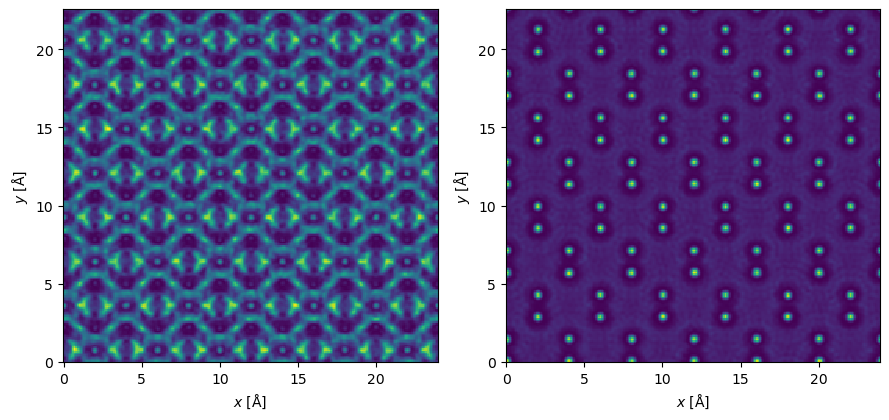

In [138]:
image_wave = exit_waves.apply_ctf(ctf)
image_wave_corrected = exit_waves.apply_ctf(ctf_corrected)

fig, ax = plt.subplots(1,2,figsize=(9,5))

image_wave.intensity().mean(0).show(
    cmap='viridis',
    ax=ax[0],
)

image_wave_corrected.intensity().mean(0).show(
    cmap='viridis',
    ax=ax[1],
)

fig.tight_layout();

Now you see why we like aberration correction! The uncorrected image shows the basic lattice periodicity, but not much else.  

Let's try settings for a TEM with lower spherical aberration (but still uncorrected). Can we tune the defocus to create a more interpretable image?  We will also apply some Gaussian blur to simulate the coherence limitations of any realistic TEM without aberration correction (due to source size effects, spatial coherence, chromatic coherence, etc.).

tasks:   0%|          | 0/56 [00:00<?, ?it/s]

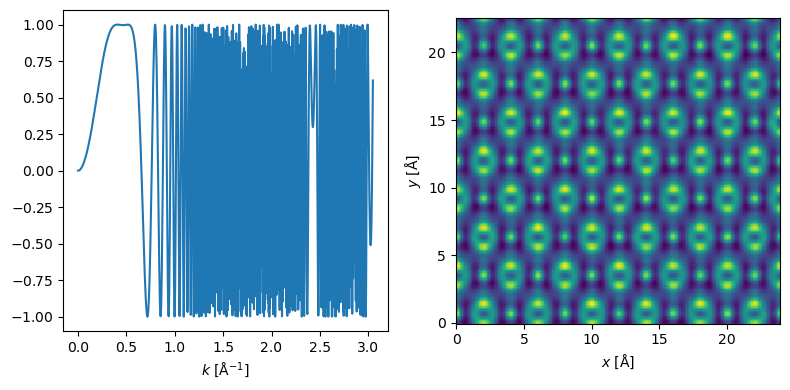

In [139]:
# No aberration correction
aberration_coefficients_interpretable = {
    "C10": -250,
    "C30": 0.3e7,  # 0.3 mm -> Å
    "C50": 5e7,    # 5.0 mm -> Å
}

ctf_interpretable = abtem.CTF(
    energy=300e3,
    aberration_coefficients=aberration_coefficients_interpretable,
)

fig, ax = plt.subplots(1, 2, figsize=(8, 4))

ctf_interpretable.profiles(max_angle=60).show(ax=ax[0], units="mrad", legend=True)

image_wave_interpretable = exit_waves.apply_ctf(ctf_interpretable)
image_wave_interpretable.intensity().mean(0).gaussian_filter(sigma=0.3).show(
    cmap="viridis",
    ax=ax[1],
)

fig.tight_layout()


As you can see, we can still make out the atomic columns in a rectangular pattern. However each of the "blobs" are actually closely spaced atomic columns (Ga-As dumbbells). Even with the best non-aberration-corrected TEM in the world, it is difficult to resolve these Ga-As dumbbells which are separated by only ~1.4 Å in projection.

Let's see what happens when we apply aberrations which are not radially symmetric.

tasks:   0%|          | 0/56 [00:00<?, ?it/s]

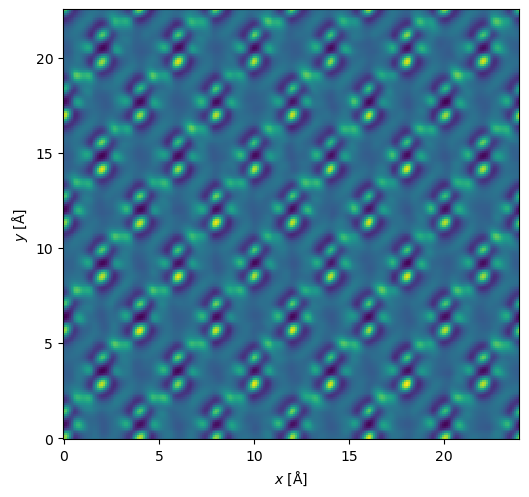

In [140]:
# Aberration corrected, negative Cs imaging
parameters_asymmetric = {
    'C10': 20,
    'C12': 20 * 1,
    'phi12': np.deg2rad(45),
    'C23': 3000 * 0.0,
    'phi23': np.deg2rad(140),
}

ctf_asymmetric = abtem.CTF(
    energy=300e3,
    aberration_coefficients=parameters_asymmetric,
)

# plot the image intensity after applying this CTF
image_wave_asymmetric = exit_waves.apply_ctf(ctf_asymmetric)
image_wave_asymmetric.intensity().mean(0).gaussian_filter(sigma = 0.2).show(
    figsize=(6,5),
    cmap='viridis',
);

## Noise

Why don't we always use zero defocus?  The reason is that we need contrast. The zero defocus plane is approximately in the center of the sample, so we apply a negative defocus to properly center the defocus. We will also apply partial coherence to the waves.

Note that our exit wave was propagated through an 80 Angstrom thick sample - therefore the "zero defocus" is actually around C10 = -40 Angstroms.

tasks:   0%|          | 0/32 [00:00<?, ?it/s]

tasks:   0%|          | 0/32 [00:00<?, ?it/s]

tasks:   0%|          | 0/32 [00:00<?, ?it/s]

tasks:   0%|          | 0/57 [00:00<?, ?it/s]

tasks:   0%|          | 0/57 [00:00<?, ?it/s]

tasks:   0%|          | 0/57 [00:00<?, ?it/s]

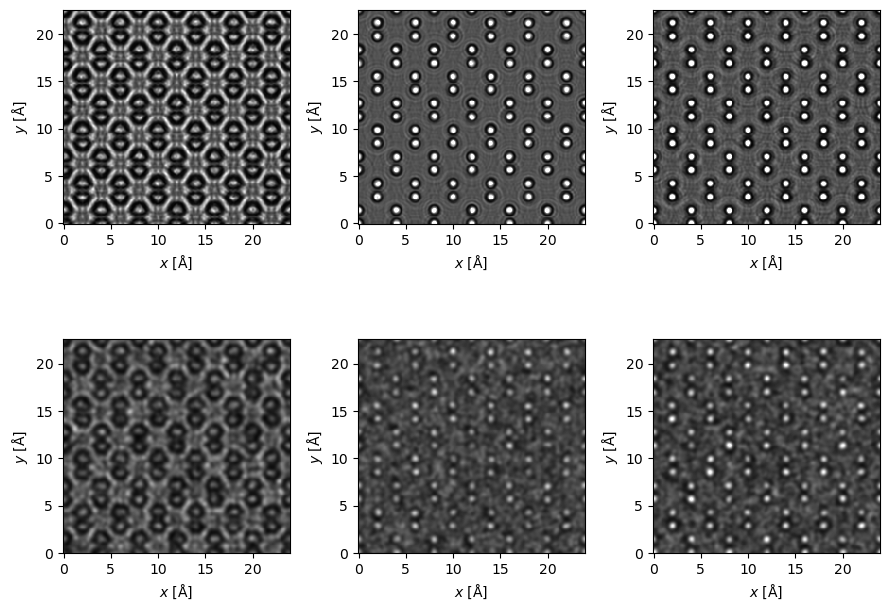

In [141]:
dose_per_area = 50  # e/Å^2
C1_values = np.array([-40, 0, 30]) - 20

ctfs = [abtem.CTF(energy=300e3, C10=C1) for C1 in C1_values]
intensities = [exit_waves.apply_ctf(ctf).intensity().mean(0) for ctf in ctfs]
noisy_intensities = [intensity.poisson_noise(dose_per_area=dose_per_area) for intensity in intensities]

fig, axs = plt.subplots(2, 3, figsize=(3 * 3, 3.5 * 2))

for ax, intensity in zip(axs[0], intensities):
    intensity.show(ax=ax, vmin=0, vmax=3.0, cmap="gray")

for ax, noisy_intensity in zip(axs[1], noisy_intensities):
    noisy_intensity.gaussian_filter(sigma=0.2).show(ax=ax, vmin=0, vmax=1.8, cmap="gray")

fig.tight_layout()


Note how the "in-focus" image has almost no contrast.

We can also see why we typically use white-atom contrast for aberration corrected HRTEM imaging - the atomic columns are sharper!